# Sentiment Analysis of Twitter/X Data
## ShadowFox Data Science Internship — Intermediate Task
### Tool Used: VADER Sentiment Analyzer

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [14]:
df = pd.read_csv('twitter_data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (162980, 2)

Columns: ['clean_text', 'category']

First 5 rows:


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


## 1. Data Exploration

In [15]:
# Check missing values and category distribution
print("Missing values:\n", df.isnull().sum())
print("\nCategory counts:\n", df['category'].value_counts())
print("\nCategory mapping: -1.0=Negative, 0.0=Neutral, 1.0=Positive")


Missing values:
 clean_text    4
category      7
dtype: int64

Category counts:
 category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

Category mapping: -1.0=Negative, 0.0=Neutral, 1.0=Positive


## 2. Data Cleaning

In [16]:
# Drop missing values
df = df.dropna(subset=['clean_text'])

# Map category numbers to labels
df['sentiment'] = df['category'].map({-1.0: 'Negative', 0.0: 'Neutral', 1.0: 'Positive'})

print("Data cleaned!")
print(df['sentiment'].value_counts())

Data cleaned!
sentiment
Positive    72249
Neutral     55211
Negative    35509
Name: count, dtype: int64


## 3. VADER Sentiment Analysis

In [17]:
# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Apply VADER to each tweet
def get_vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    if score['compound'] >= 0.05:
        return 'Positive'
    elif score['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply on sample of 10000 rows (full dataset is too large)
df_sample = df.sample(n=10000, random_state=42)
df_sample['vader_sentiment'] = df_sample['clean_text'].apply(get_vader_sentiment)

print("VADER analysis complete!")
print(df_sample['vader_sentiment'].value_counts())

VADER analysis complete!
vader_sentiment
Positive    4712
Negative    3152
Neutral     2136
Name: count, dtype: int64


## 4. Visualizations

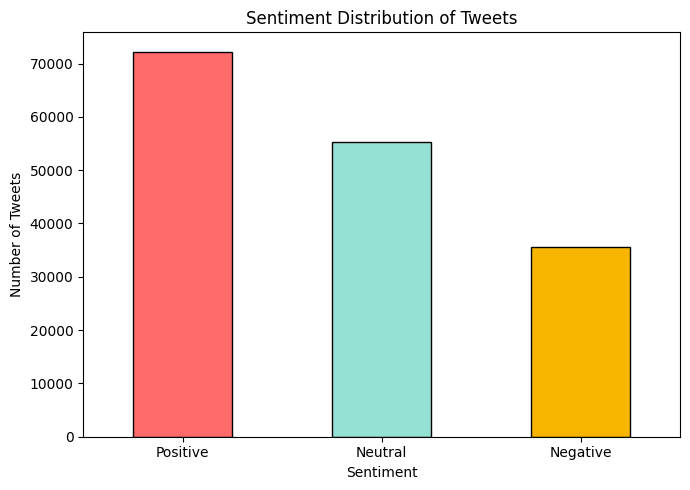

Total tweets analyzed: 162976


In [18]:
# Bar chart of sentiment distribution
plt.figure(figsize=(7, 5))
colors = ['#ff6b6b', '#95e1d3', '#f8b500']
df['sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title("Sentiment Distribution of Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("Total tweets analyzed:", len(df))

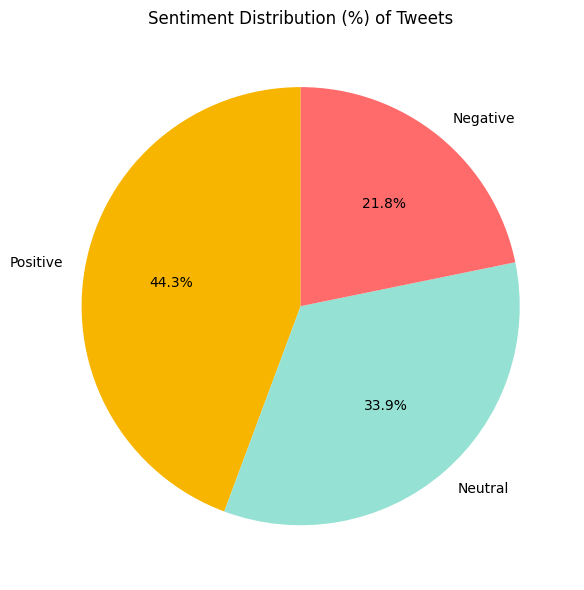

In [19]:
# Pie chart
plt.figure(figsize=(6, 6))
sizes = df['sentiment'].value_counts()
colors = ['#f8b500', '#95e1d3', '#ff6b6b']
plt.pie(sizes, labels=sizes.index, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title("Sentiment Distribution (%) of Tweets")
plt.tight_layout()
plt.show()

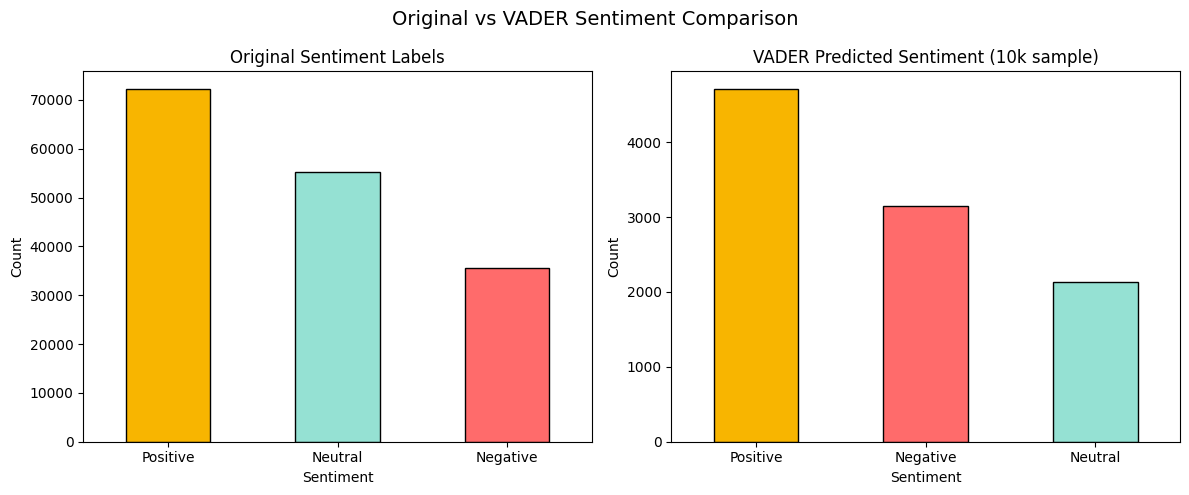

In [20]:
# Compare original vs VADER sentiment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original labels
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#f8b500', '#95e1d3', '#ff6b6b'], edgecolor='black')
axes[0].set_title("Original Sentiment Labels")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# VADER labels
df_sample['vader_sentiment'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#f8b500', '#ff6b6b', '#95e1d3'], edgecolor='black')
axes[1].set_title("VADER Predicted Sentiment (10k sample)")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("Original vs VADER Sentiment Comparison", fontsize=14)
plt.tight_layout()
plt.show()

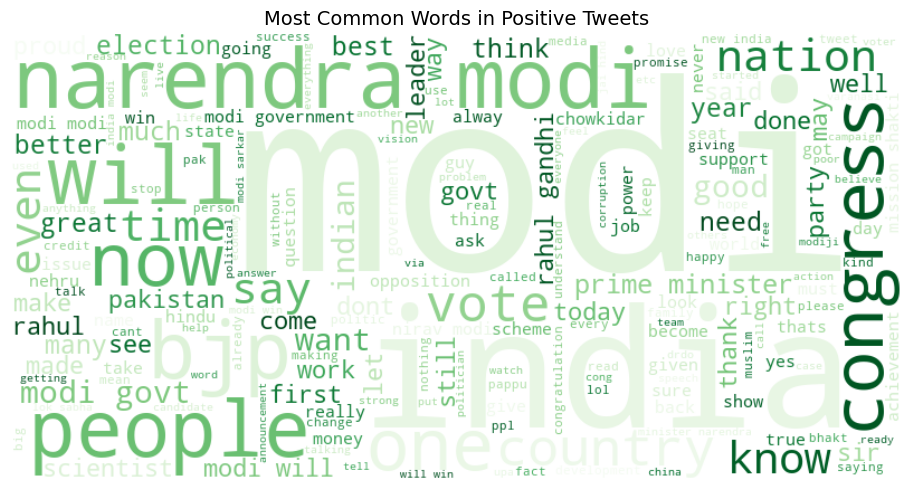

In [21]:
# Wordcloud for positive tweets
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['clean_text'].dropna())

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Greens').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Positive Tweets", fontsize=14)
plt.tight_layout()
plt.show()

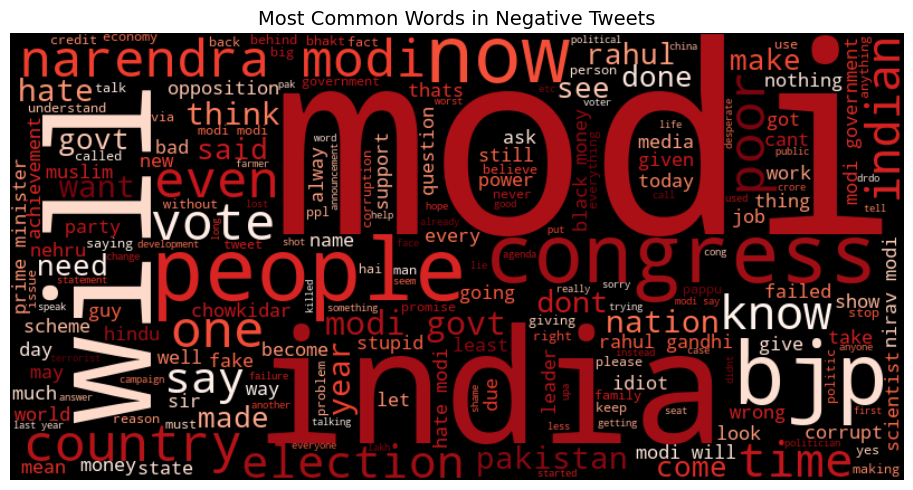

In [22]:
# Wordcloud for negative tweets
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['clean_text'].dropna())

wordcloud = WordCloud(width=800, height=400,
                      background_color='black',
                      colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Negative Tweets", fontsize=14)
plt.tight_layout()
plt.show()

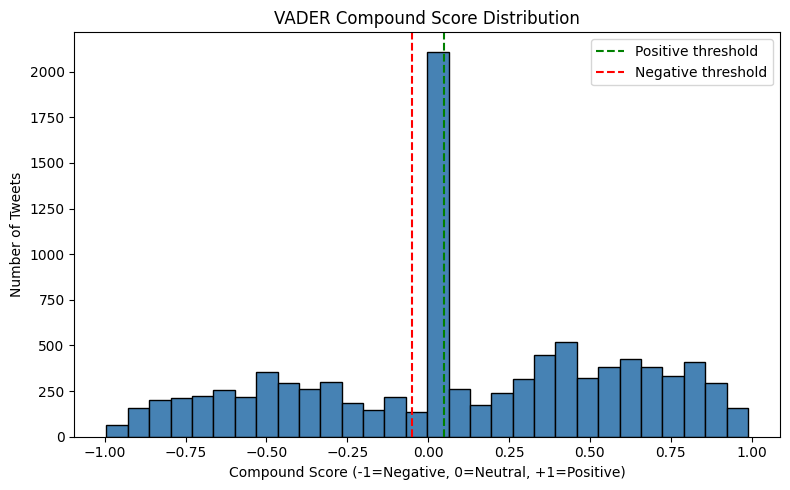

In [23]:
# VADER compound score distribution
df_sample['compound_score'] = df_sample['clean_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound'])

plt.figure(figsize=(8, 5))
plt.hist(df_sample['compound_score'], bins=30,
         color='steelblue', edgecolor='black')
plt.title("VADER Compound Score Distribution")
plt.xlabel("Compound Score (-1=Negative, 0=Neutral, +1=Positive)")
plt.ylabel("Number of Tweets")
plt.axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
plt.axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Conclusion

- Dataset contains 162,980 tweets with 3 sentiment categories
- Majority of tweets are Positive (44.3%) followed by Neutral (33.9%) and Negative (21.8%)
- VADER Sentiment Analyzer was applied on a sample of 10,000 tweets
- VADER predicted similar trend — more Positive tweets than Negative
- WordCloud shows common words used in Positive and Negative tweets
- VADER compound score distribution shows most tweets lean slightly Positive